In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Reproducibility
np.random.seed(42)

# Create Taxi environment with text rendering
env = gym.make("Taxi-v3", render_mode="ansi")

print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)


Number of states: 500
Number of actions: 6


In [2]:
def reset_env(env):
    """
    Reset the environment and return only the observation (state id).
    """
    obs, info = env.reset()
    return obs

def step_env(env, action):
    """
    Step the environment and unify Gymnasium's output into:
    next_state, reward, done, info.
    """
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    return obs, reward, done, info

def render_env(env):
    """Print the ASCII Taxi grid."""
    print(env.render())

# Optional: action meanings (handy for debugging / slides)
action_meaning = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff",
}

for a in range(env.action_space.n):
    print(a, ":-", action_meaning[a])


0 :- South
1 :- North
2 :- East
3 :- West
4 :- Pickup
5 :- Dropoff


In [3]:
state_space_size  = env.observation_space.n   # 500
action_space_size = env.action_space.n        # 6

# Training config
num_episodes = 20000
max_steps    = 200

# Learning hyperparameters
alpha = 0.1      # learning rate
gamma = 0.99     # discount factor

# Epsilon (exploration) schedule: exponential from 1.0 → 0.05 over 3000 episodes
epsilon_start = 1.0
epsilon_end   = 0.05
decay_episodes = 3000

epsilon_decay = (epsilon_end / epsilon_start) ** (1.0 / decay_episodes)
min_epsilon   = epsilon_end

print("State space size:", state_space_size)
print("Action space size:", action_space_size)
print("Epsilon decay per episode:", epsilon_decay)


State space size: 500
Action space size: 6
Epsilon decay per episode: 0.9990019209880034


In [4]:
def train_double_q_learning(env,
                            num_episodes,
                            max_steps,
                            alpha,
                            gamma,
                            epsilon_start,
                            epsilon_decay,
                            min_epsilon):
    """
    Train a Double Q-learning agent on Taxi-v3.

    We maintain two Q-tables, Q1 and Q2.
    - For action selection, we use ε-greedy over (Q1 + Q2).
    - On each step, we randomly choose to update Q1 (using Q2's estimate)
      or Q2 (using Q1's estimate).
    - For terminal transitions (done=True), we bootstrap with just the reward
      (no future term).

    Returns:
      Q1, Q2        - learned Q-tables
      rewards       - total reward per episode (list)
      epsilons      - epsilon value per episode (list)
    """
    state_space_size  = env.observation_space.n
    action_space_size = env.action_space.n

    Q1 = np.zeros((state_space_size, action_space_size))
    Q2 = np.zeros((state_space_size, action_space_size))

    epsilon = epsilon_start
    rewards = []
    epsilons = []

    for ep in range(num_episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        for step in range(max_steps):
            # --- ε-greedy action selection using combined estimate ---
            Q_sum = Q1[state] + Q2[state]

            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_sum)

            next_state, reward, done, info = step_env(env, action)

            # --- Double Q update ---
            if np.random.rand() < 0.5:
                # Update Q1, evaluate next state using Q2
                a_max = np.argmax(Q1[next_state])

                if done:
                    target = reward          # no bootstrapping on terminal
                else:
                    target = reward + gamma * Q2[next_state, a_max]

                old_value = Q1[state, action]
                Q1[state, action] = old_value + alpha * (target - old_value)

            else:
                # Update Q2, evaluate next state using Q1
                a_max = np.argmax(Q2[next_state])

                if done:
                    target = reward
                else:
                    target = reward + gamma * Q1[next_state, a_max]

                old_value = Q2[state, action]
                Q2[state, action] = old_value + alpha * (target - old_value)

            state = next_state
            total_reward += reward

            if done:
                break

        # decay epsilon after each episode
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

        rewards.append(total_reward)
        epsilons.append(epsilon)

        # progress log
        if (ep + 1) % 500 == 0:
            print(
                f"[Double Q] Episode {ep+1}/{num_episodes} | "
                f"Total reward: {total_reward:5.1f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    return Q1, Q2, rewards, epsilons


In [5]:
print("Training Double Q-learning agent...")

Q1_dq, Q2_dq, rewards_dq, eps_dq = train_double_q_learning(
    env,
    num_episodes=num_episodes,
    max_steps=max_steps,
    alpha=alpha,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_decay=epsilon_decay,
    min_epsilon=min_epsilon,
)

print("\nDouble Q-learning - average reward (last 100 episodes):",
      np.mean(rewards_dq[-100:]))


Training Double Q-learning agent...
[Double Q] Episode 500/20000 | Total reward: -238.0 | Epsilon: 0.607
[Double Q] Episode 1000/20000 | Total reward: -150.0 | Epsilon: 0.368
[Double Q] Episode 1500/20000 | Total reward: -304.0 | Epsilon: 0.224
[Double Q] Episode 2000/20000 | Total reward: -15.0 | Epsilon: 0.136
[Double Q] Episode 2500/20000 | Total reward:   2.0 | Epsilon: 0.082
[Double Q] Episode 3000/20000 | Total reward:  12.0 | Epsilon: 0.050
[Double Q] Episode 3500/20000 | Total reward:   4.0 | Epsilon: 0.050
[Double Q] Episode 4000/20000 | Total reward:  11.0 | Epsilon: 0.050
[Double Q] Episode 4500/20000 | Total reward:   3.0 | Epsilon: 0.050
[Double Q] Episode 5000/20000 | Total reward:  11.0 | Epsilon: 0.050
[Double Q] Episode 5500/20000 | Total reward:  12.0 | Epsilon: 0.050
[Double Q] Episode 6000/20000 | Total reward: -13.0 | Epsilon: 0.050
[Double Q] Episode 6500/20000 | Total reward:   9.0 | Epsilon: 0.050
[Double Q] Episode 7000/20000 | Total reward:  -3.0 | Epsilon: 0.

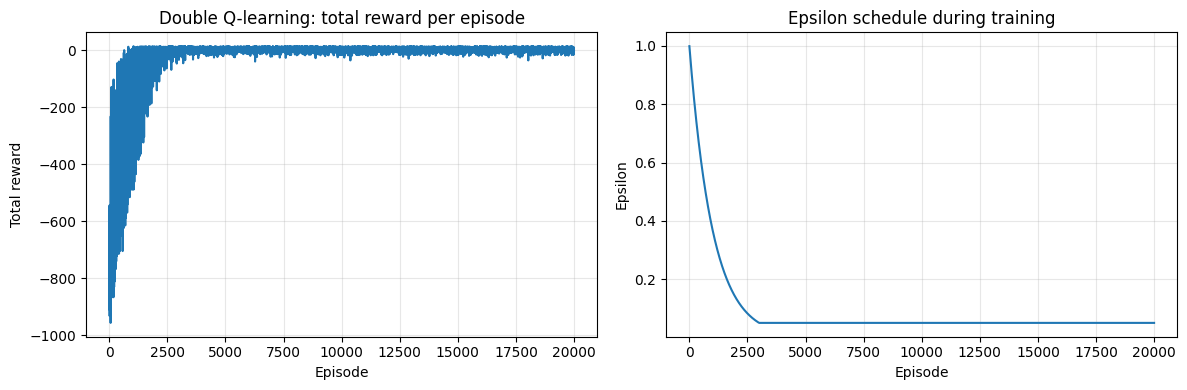

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Reward curve
ax[0].plot(rewards_dq)
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Total reward")
ax[0].set_title("Double Q-learning: total reward per episode")
ax[0].grid(True, alpha=0.3)

# Epsilon curve
ax[1].plot(eps_dq)
ax[1].set_xlabel("Episode")
ax[1].set_ylabel("Epsilon")
ax[1].set_title("Epsilon schedule during training")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
def evaluate_double_q(env, Q1, Q2, episodes=3000, max_steps=200):
    """
    Evaluate a trained Double Q-learning agent by acting greedily
    w.r.t. Q1 + Q2.

    Returns:
      rewards    - list of total rewards per episode
      steps_list - list of steps per episode
    """
    rewards = []
    steps_list = []

    for ep in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            Q_sum = Q1[state] + Q2[state]
            action = np.argmax(Q_sum)

            state, reward, done, info = step_env(env, action)
            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list


In [8]:
greedy_rewards_dq, greedy_steps_dq = evaluate_double_q(env, Q1_dq, Q2_dq)

print("=== Double Q-learning: Greedy Evaluation over 3000 episodes ===")
print("Avg reward:", np.mean(greedy_rewards_dq))
print("Avg steps :", np.mean(greedy_steps_dq))
print("Max reward:", np.max(greedy_rewards_dq))
print("Min reward:", np.min(greedy_rewards_dq))
print("Max steps :", np.max(greedy_steps_dq))
print("Min steps :", np.min(greedy_steps_dq))


=== Double Q-learning: Greedy Evaluation over 3000 episodes ===
Avg reward: 7.966333333333333
Avg steps : 13.033666666666667
Max reward: 15
Min reward: 3
Max steps : 18
Min steps : 6


In [9]:
# One full episode run using Double Q-learning table

state = reset_env(env)
total_reward = 0
steps = 0
done = False
max_steps = 200

action_names = ["South", "North", "East", "West", "Pickup", "Dropoff"]

print("=== DOUBLE Q-LEARNING EPISODE (greedy w.r.t Q1+Q2, 1 run) ===")
print(f"Initial encoded state: {state}")
r, c, p_idx, d_idx = env.unwrapped.decode(state)
print(f"Decoded: taxi=({r},{c}), passenger_idx={p_idx}, dest_idx={d_idx}")
render_env(env)

while not done and steps < max_steps:
    row, col, pass_idx, dest_idx = env.unwrapped.decode(state)

    print("\n-------------------------------------------------")
    print(f"Current state (step {steps}): taxi=({row},{col}), "
          f"pass_idx={pass_idx}, dest_idx={dest_idx}")

    # Greedy action selection using Double Q-learning (Q1 + Q2)
    q1_values = Q1_dq[state]
    q2_values = Q2_dq[state]
    q_sum = q1_values + q2_values
    action = int(np.argmax(q_sum))

    print(f"Q1[state]: {q1_values}")
    print(f"Q2[state]: {q2_values}")
    print(f"Q1+Q2   : {q_sum}")
    print(f"Chosen action: {action} ({action_names[action]})")

    # Take step in environment
    next_state, reward, done, info = step_env(env, action)
    steps += 1
    total_reward += reward

    print(f"Step {steps:02d}:")
    print(f"  Reward: {reward}, Done: {done}")
    r2, c2, p2, d2 = env.unwrapped.decode(next_state)
    print(f"  Next decoded state: taxi=({r2},{c2}), "
          f"pass_idx={p2}, dest_idx={d2}")

    render_env(env)

    state = next_state

print("\n=== EPISODE FINISHED (Double Q-learning) ===")
print(f"Total steps: {steps}")
print(f"Total reward: {total_reward}")


=== DOUBLE Q-LEARNING EPISODE (greedy w.r.t Q1+Q2, 1 run) ===
Initial encoded state: 69
Decoded: taxi=(0,3), passenger_idx=2, dest_idx=1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



-------------------------------------------------
Current state (step 0): taxi=(0,3), pass_idx=2, dest_idx=1
Q1[state]: [  2.05866446  -8.88465488  -9.93270712  -9.0082257  -13.88572524
 -15.42624844]
Q2[state]: [  1.75847556  -9.79987028  -9.73684249  -8.76209946 -15.23361351
 -13.89229317]
Q1+Q2   : [  3.81714002 -18.68452516 -19.66954961 -17.77032517 -29.11933875
 -29.31854161]
Chosen action: 0 (South)
Step 01:
  Reward: -1, Done: False
  Next decoded state: taxi=(1,3), pass_idx=2, dest_idx=1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)


-------------------------------------------------
Current state (step 1): taxi=(1,3), pass_idx=2, dest_idx=1
Q1[state]: [ -9.64636183  -7.22006312  -9.57708282   3.20610881 -12.78